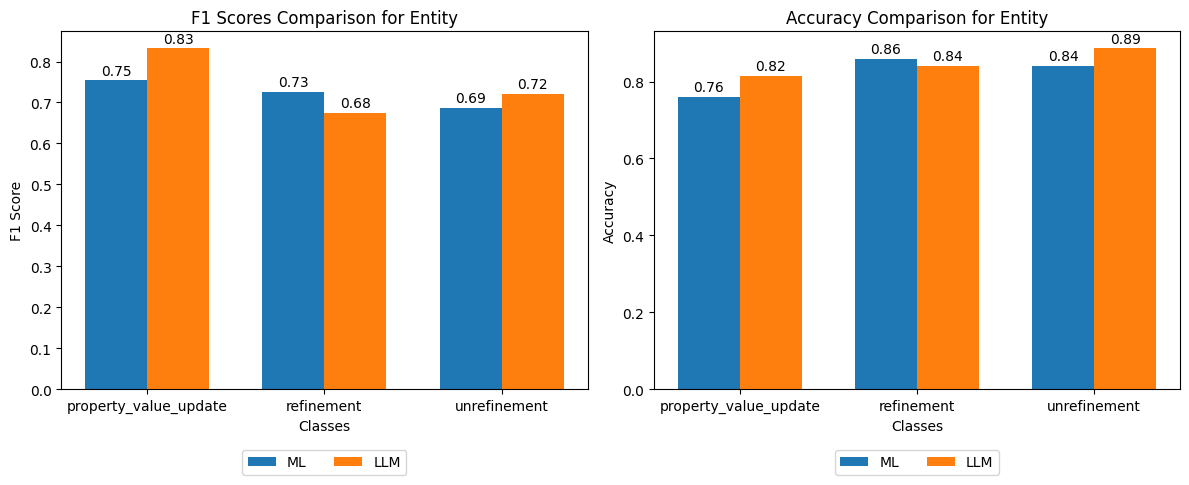

In [1]:
import pickle
import matplotlib.pyplot as plt
import json
import numpy as np

TRAINING_INFO_DIR = 'ml/training_info'

with open(f'{TRAINING_INFO_DIR}/best_model_training_info_entity.pkl', 'rb') as f:
    training_info_model = pickle.load(f)

micro_averages_entity = training_info_model['entity']['micro_averages']

with open(f'llm/results/llm_classification.json', 'r') as f:
    results_llm = json.load(f)

results_llm_entity = results_llm['entity']

x = list(results_llm_entity.keys())
x_pos = np.arange(len(x))
width = 0.35

f1_ml = [micro_averages_entity[class_]['f1'] for class_ in x]
f1_llm = [results_llm_entity[class_]['f1'] for class_ in x]

acc_ml = [micro_averages_entity[class_]['accuracy'] for class_ in x]
avg_acc_ml = np.mean(acc_ml)
acc_llm = [results_llm_entity[class_]['accuracy'] for class_ in x]
avg_acc_llm = np.mean(acc_llm)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(x_pos - width/2, f1_ml, width=width, label='ML', align='center')
bars2 = axes[0].bar(x_pos + width/2, f1_llm, width=width, label='LLM', align='center')
axes[0].bar_label(bars1, fmt='%.2f', padding=2)
axes[0].bar_label(bars2, fmt='%.2f', padding=2)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x)
axes[0].set_title('F1 Scores Comparison for Entity')
axes[0].set_xlabel('Classes')
axes[0].set_ylabel('F1 Score')


bars3 = axes[1].bar(x_pos - width/2, acc_ml, width=width, label='ML', align='center')
bars4 = axes[1].bar(x_pos + width/2, acc_llm, width=width, label='LLM', align='center')
axes[1].bar_label(bars3, fmt='%.2f', padding=2)
axes[1].bar_label(bars4, fmt='%.2f', padding=2)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x)
axes[1].set_title('Accuracy Comparison for Entity')
axes[1].set_xlabel('Classes')
axes[1].set_ylabel('Accuracy')

axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncols=2)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncols=2)

plt.tight_layout()
plt.show()




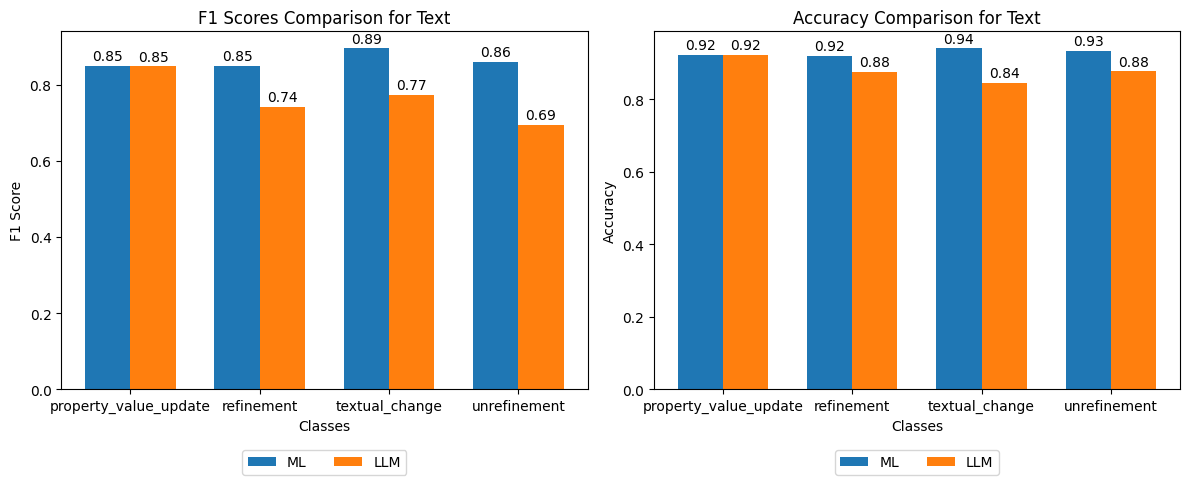

In [2]:
import pickle
import matplotlib.pyplot as plt
import json
import numpy as np

TRAINING_INFO_DIR = 'ml/training_info'

with open(f'{TRAINING_INFO_DIR}/best_model_training_info_text.pkl', 'rb') as f:
    training_info_model = pickle.load(f)

micro_averages_text = training_info_model['text']['micro_averages']

with open(f'llm/results/llm_classification.json', 'r') as f:
    results_llm = json.load(f)

results_llm_text = results_llm['text']

x = list(results_llm_text.keys())
x_pos = np.arange(len(x))
width = 0.35

f1_ml = [micro_averages_text[class_]['f1'] for class_ in x]
f1_llm = [results_llm_text[class_]['f1'] for class_ in x]

acc_ml = [micro_averages_text[class_]['accuracy'] for class_ in x]
acc_llm = [results_llm_text[class_]['accuracy'] for class_ in x]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(x_pos - width/2, f1_ml, width=width, label='ML', align='center')
bars2 = axes[0].bar(x_pos + width/2, f1_llm, width=width, label='LLM', align='center')
axes[0].bar_label(bars1, fmt='%.2f', padding=2)
axes[0].bar_label(bars2, fmt='%.2f', padding=2)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(x)
axes[0].set_title('F1 Scores Comparison for Text')
axes[0].set_xlabel('Classes')
axes[0].set_ylabel('F1 Score')


bars3 = axes[1].bar(x_pos - width/2, acc_ml, width=width, label='ML', align='center')
bars4 = axes[1].bar(x_pos + width/2, acc_llm, width=width, label='LLM', align='center')
axes[1].bar_label(bars3, fmt='%.2f', padding=2)
axes[1].bar_label(bars4, fmt='%.2f', padding=2)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(x)
axes[1].set_title('Accuracy Comparison for Text')
axes[1].set_xlabel('Classes')
axes[1].set_ylabel('Accuracy')

axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncols=2)
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncols=2)

plt.tight_layout()
plt.show()

# NOTE: 
# For text I only give old_value and new_value
# For entity I give old_value, new_value, old_value_label, new_value_label, old_value_description, new_value_description
# Example of where it fails:
# """Wife of Count Folke Bernadotte (1904-1984)""","""American-Swedish countess""",property_value_update,"refinement, unrefinement"
# As it is, the old value is completely different from the new value, the new one is not adding information
# to the old one, it's a different description entirely, the new one is a title and the old one talks about her husband and 
# birth-death....


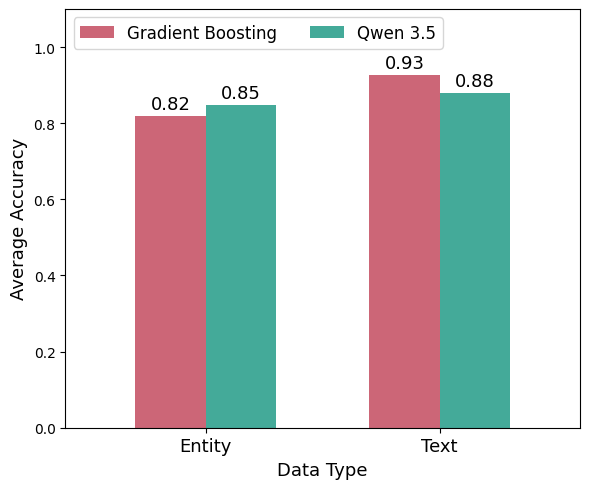

In [3]:
import pickle
import matplotlib.pyplot as plt
import json
import numpy as np

TRAINING_INFO_DIR = 'ml/training_info'

with open(f'{TRAINING_INFO_DIR}/best_model_training_info_entity.pkl', 'rb') as f:
    training_info_model_entity = pickle.load(f)

micro_averages_entity = training_info_model_entity['entity']['micro_averages']

with open(f'{TRAINING_INFO_DIR}/best_model_training_info_text.pkl', 'rb') as f:
    training_info_model_text = pickle.load(f)

micro_averages_text = training_info_model_text['text']['micro_averages']

with open(f'llm/results/llm_classification.json', 'r') as f:
    results_llm = json.load(f)

results_llm_entity = results_llm['entity']
results_llm_text = results_llm['text']

METRIC = 'accuracy'  # change to 'f1' if you want F1 instead
 
entity_labels = list(results_llm_entity.keys())
text_labels = list(results_llm_text.keys())
 
avg_ml_entity = np.mean([micro_averages_entity[c][METRIC] for c in entity_labels])
avg_llm_entity = np.mean([results_llm_entity[c][METRIC] for c in entity_labels])
avg_ml_text = np.mean([micro_averages_text[c][METRIC] for c in text_labels])
avg_llm_text = np.mean([results_llm_text[c][METRIC] for c in text_labels])
 
groups = ['Entity', 'Text']
ml_values = [avg_ml_entity, avg_ml_text]
llm_values = [avg_llm_entity, avg_llm_text]
 
x_pos = np.arange(len(groups))*0.5
width = 0.15
 
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
 
bars_ml = ax.bar(x_pos - width / 2, ml_values, width=width, label='Gradient Boosting', color='#CC6677')
bars_llm = ax.bar(x_pos + width / 2, llm_values, width=width, label='Qwen 3.5', color='#44AA99')
 
ax.bar_label(bars_ml, fmt='%.2f', padding=2, fontsize=13)
ax.bar_label(bars_llm, fmt='%.2f', padding=2, fontsize=13)
 
ax.set_xticks(x_pos)
ax.set_xticklabels(groups, fontsize=13)
ax.set_xlim(x_pos[0] - 0.3, x_pos[-1] + 0.3)
ax.set_xlabel('Data Type', fontsize=13)
ax.set_ylabel(f'Average {METRIC.capitalize()}', fontsize=13)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=12, ncols=2, loc='upper left')
 
plt.tight_layout()
plt.savefig('ml_vs_llm_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
import json
import pickle

with open(f'ml/training_info/best_model_training_info_entity.pkl', 'rb') as f:
    training_info_model = pickle.load(f)

micro_averages_entity = training_info_model['entity']['micro_averages']
print('ENTITY CLASSIFICATION')
for label, metrics in micro_averages_entity.items():
    # \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} & \textbf{F1}
    print(f"{label} & {metrics['accuracy']:.2f} & {metrics['precision']:.2f} & {metrics['recall']:.2f} & {metrics['f1']:.2f} \\\\")

print()
print('TEXT CLASSIFICATION')

with open(f'ml/training_info/best_model_training_info_text.pkl', 'rb') as f:
    training_info_model = pickle.load(f)

micro_averages_entity = training_info_model['text']['micro_averages']

for label, metrics in micro_averages_entity.items():
    # \textbf{Accuracy} & \textbf{Precision} & \textbf{Recall} & \textbf{F1}
    print(f"{label} & {metrics['accuracy']:.2f} & {metrics['precision']:.2f} & {metrics['recall']:.2f} & {metrics['f1']:.2f} \\\\")

ENTITY CLASSIFICATION
property_value_update & 0.76 & 0.83 & 0.69 & 0.75 \\
refinement & 0.86 & 0.67 & 0.80 & 0.73 \\
unrefinement & 0.84 & 0.63 & 0.75 & 0.69 \\

TEXT CLASSIFICATION
property_value_update & 0.92 & 0.85 & 0.85 & 0.85 \\
refinement & 0.92 & 0.83 & 0.87 & 0.85 \\
textual_change & 0.94 & 0.90 & 0.89 & 0.89 \\
unrefinement & 0.93 & 0.89 & 0.83 & 0.86 \\
